In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# ==========================================
# 1. Load full dataset
# ==========================================
# Local path auto-detection: current folder first, then common subfolders
csv_candidates = [
    Path('musicvideo3.csv'),
    Path('data/musicvideo3.csv'),
    Path('./musicvideo3.csv'),
]

file_path = next((p for p in csv_candidates if p.exists()), None)
if file_path is None:
    raise FileNotFoundError(
        f"CSV not found. Tried: {[str(p) for p in csv_candidates]}; cwd={Path.cwd()}"
    )

print(f"Using dataset: {file_path.resolve()}")

# Read required columns and skip header row
df = pd.read_csv(
    file_path,
    encoding_errors='ignore',
    usecols=[2, 5, 6, 7],
    names=['title', 'publish_time', 'tags', 'views'],
    skiprows=1
)

print(f"Initial records (with duplicates): {len(df)}")

# ==========================================
# 2. Data cleaning and deduplication
# ==========================================
# Convert views to numeric first (avoid string-based ordering issues)
df['views'] = pd.to_numeric(df['views'], errors='coerce')

# Drop rows with missing critical fields
df = df.dropna(subset=['views', 'tags', 'title']).reset_index(drop=True)

# Deduplicate by title, keeping the highest-views record
df = (
    df.sort_values('views', ascending=False)
      .drop_duplicates(subset=['title'], keep='first')
      .reset_index(drop=True)
)

print(f"Unique videos after dedup: {len(df)}")



Using dataset: C:\Users\Leo\Desktop\ECE227_Final_Youtube\musicvideo3.csv
Initial records (with duplicates): 23957
Unique videos after dedup: 2547


已保存图片: 1_views_distribution_unique.png


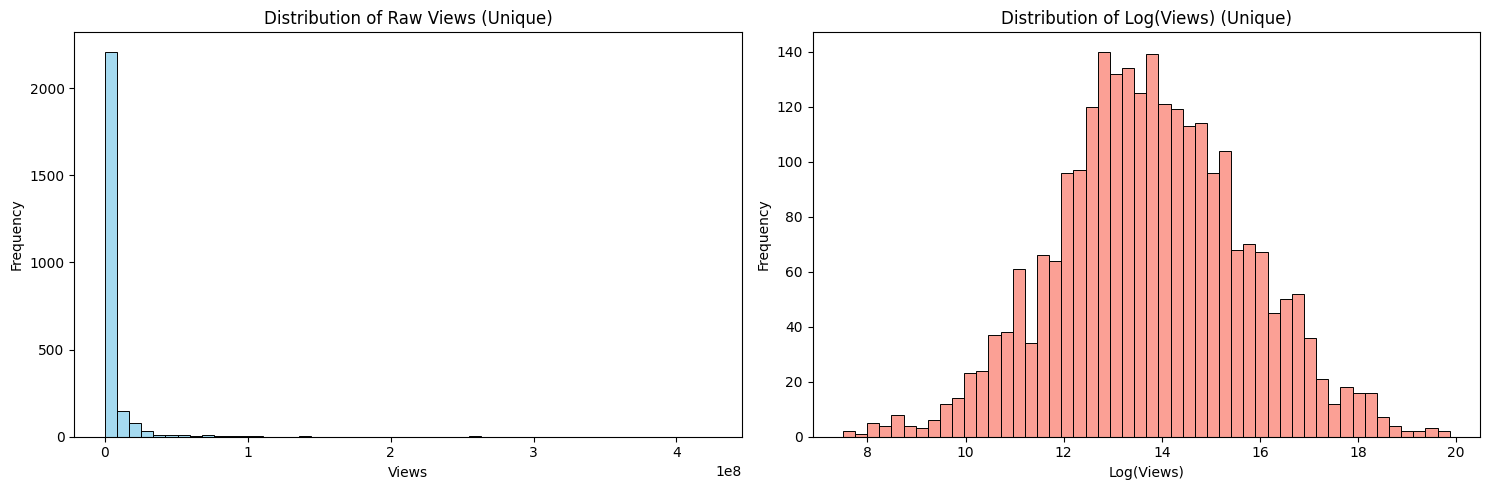

已保存图片: 2_tag_frequency_powerlaw_unique.png


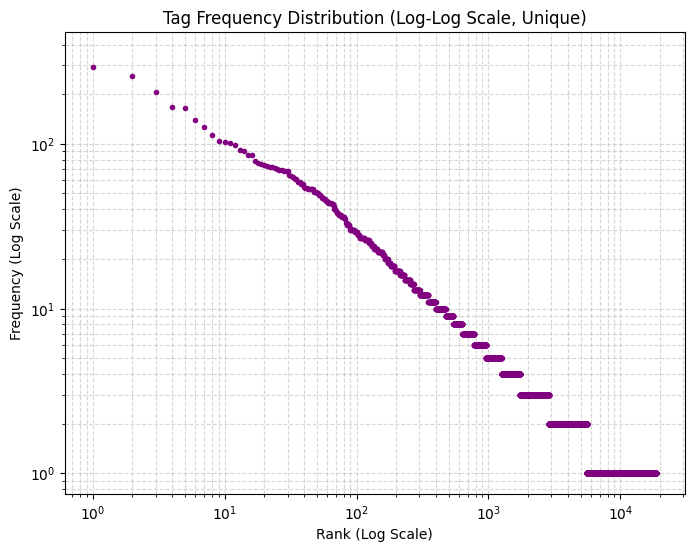

In [2]:
# ==========================================
# 3. 特征提取
# ==========================================
# 计算 log(views)
df['log_views'] = df['views'].apply(lambda x: math.log(x) if x > 0 else 0)
max_views = df['views'].max()

# 清洗 tags 列：去除多余的引号，并按 '|' 分割成列表
df['cleaned_tags'] = df['tags'].astype(str).str.replace('"', '').str.lower().str.split('|')

# ==========================================
# 4. 数据可视化 - 播放量分布
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 原始 Views 分布
sns.histplot(df['views'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Raw Views (Unique)')
axes[0].set_xlabel('Views')
axes[0].set_ylabel('Frequency')

# Log(Views) 分布
sns.histplot(df['log_views'], bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Log(Views) (Unique)')
axes[1].set_xlabel('Log(Views)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('1_views_distribution_unique.png', dpi=300, bbox_inches='tight')
print("已保存图片: 1_views_distribution_unique.png")
plt.show()

# ==========================================
# 5. 数据可视化 - 验证幂律分布
# ==========================================
all_tags = [tag for sublist in df['cleaned_tags'] for tag in sublist if tag.strip() != '']
tag_counts = Counter(all_tags)
frequencies = sorted(list(tag_counts.values()), reverse=True)

plt.figure(figsize=(8, 6))
plt.plot(frequencies, marker='.', linestyle='none', color='purple')
plt.xscale('log')
plt.yscale('log')
plt.title('Tag Frequency Distribution (Log-Log Scale, Unique)')
plt.xlabel('Rank (Log Scale)')
plt.ylabel('Frequency (Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.savefig('2_tag_frequency_powerlaw_unique.png', dpi=300, bbox_inches='tight')
print("已保存图片: 2_tag_frequency_powerlaw_unique.png")
plt.show()

正在构建基于 log_views 的宏观网络，当前阈值 threshold = 0.015...
建图完成！耗时: 0.04 秒

--- 网络诊断信息 ---
节点总数: 2547
连边总数: 14279
网络密度: 0.004404 (一般在 0.001 - 0.05 之间比较适合社区发现)
总连通分量数量: 123
前 5 大连通分量的节点数: [1531, 196, 151, 94, 39]
==> 提取的最大连通分量 (LCC) 节点数: 1531 (占总数据 60.11%)

已保存图片: 3_macro_network_diagnostics.png


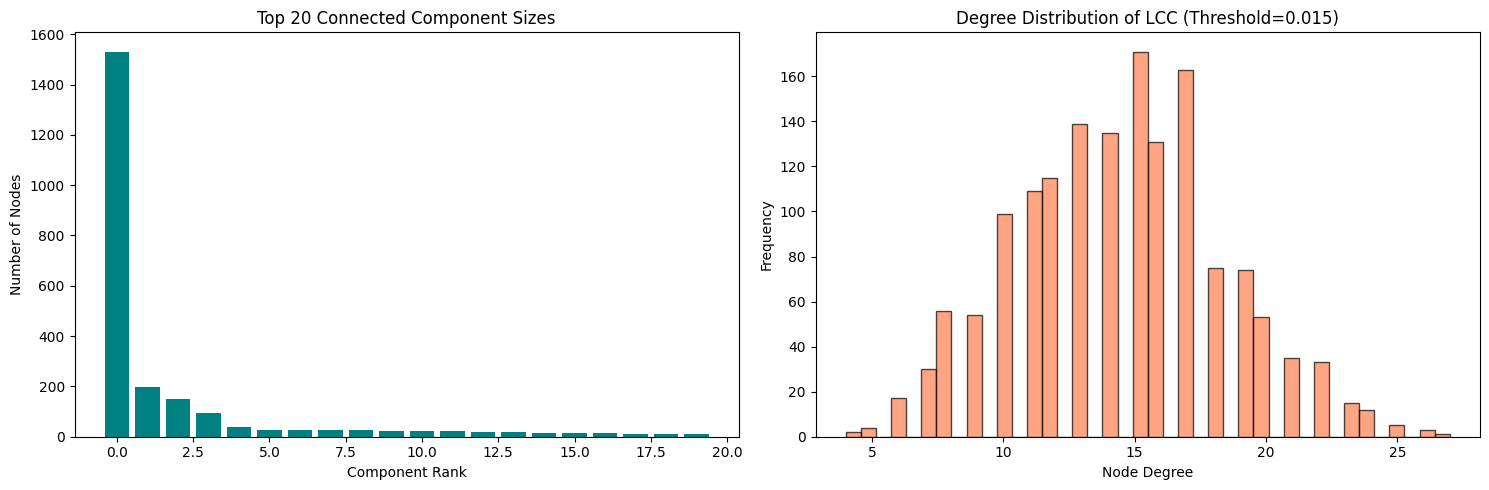

In [3]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. 设定关键参数（基于 log_views 差值的阈值）
# ==========================================
threshold_views = 0.015

print(f"正在构建基于 log_views 的宏观网络，当前阈值 threshold = {threshold_views}...")
start_time = time.time()

# ==========================================
# 2. 构建网络图
# ==========================================
G_views = nx.Graph()

# 添加节点，并将有用的属性（标题、log播放量、清洗后的标签）存入节点中
for idx, row in df.iterrows():
    G_views.add_node(idx, title=row['title'], log_views=row['log_views'], tags=row['cleaned_tags'])

# 高效建边逻辑：按 log_views 排序，只和相近的视频比较，避免 O(N^2) 的双重循环
nodes_data = df[['log_views']].sort_values(by='log_views').reset_index()
node_indices = nodes_data['index'].values
log_views_vals = nodes_data['log_views'].values

edges_to_add = []
n = len(node_indices)
for i in range(n):
    u = node_indices[i]
    val_u = log_views_vals[i]
    # 只往后找，直到差值超过阈值
    for j in range(i + 1, n):
        v = node_indices[j]
        val_v = log_views_vals[j]
        if (val_v - val_u) <= threshold_views:
            edges_to_add.append((u, v))
        else:
            break  # 一旦超过阈值，因为是排好序的，后面的差值肯定更大，直接跳出内层循环

G_views.add_edges_from(edges_to_add)
print(f"建图完成！耗时: {time.time() - start_time:.2f} 秒")

# ==========================================
# 3. 网络诊断与连通分量分析
# ==========================================
num_nodes = G_views.number_of_nodes()
num_edges = G_views.number_of_edges()
density = nx.density(G_views)

print(f"\n--- 网络诊断信息 ---")
print(f"节点总数: {num_nodes}")
print(f"连边总数: {num_edges}")
print(f"网络密度: {density:.6f} (一般在 0.001 - 0.05 之间比较适合社区发现)")

# 获取所有的连通分量
components = list(nx.connected_components(G_views))
components_sizes = [len(c) for c in components]
components_sizes.sort(reverse=True)

print(f"总连通分量数量: {len(components)}")
print(f"前 5 大连通分量的节点数: {components_sizes[:5]}")

# 提取最大连通分量 (LCC)
lcc_nodes = max(components, key=len)
G_lcc = G_views.subgraph(lcc_nodes).copy()
print(f"==> 提取的最大连通分量 (LCC) 节点数: {G_lcc.number_of_nodes()} (占总数据 {G_lcc.number_of_nodes()/num_nodes*100:.2f}%)")

# ==========================================
# 4. 可视化评估与保存
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 图 A：连通分量大小分布 (看看网络有没有碎成太多块)
axes[0].bar(range(min(20, len(components_sizes))), components_sizes[:20], color='teal')
axes[0].set_title('Top 20 Connected Component Sizes')
axes[0].set_xlabel('Component Rank')
axes[0].set_ylabel('Number of Nodes')

# 图 B：最大连通分量(LCC)的度分布
degrees = [d for n, d in G_lcc.degree()]
axes[1].hist(degrees, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Degree Distribution of LCC (Threshold={threshold_views})')
axes[1].set_xlabel('Node Degree')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('3_macro_network_diagnostics.png', dpi=300, bbox_inches='tight')
print("\n已保存图片: 3_macro_network_diagnostics.png")
plt.show()

开始准备宏观网络可视化数据...
正在计算网络布局 (包含 2011 个节点)，请稍候...
布局计算完成！耗时: 3.68 秒

已保存图片: 4_macro_network_components.png


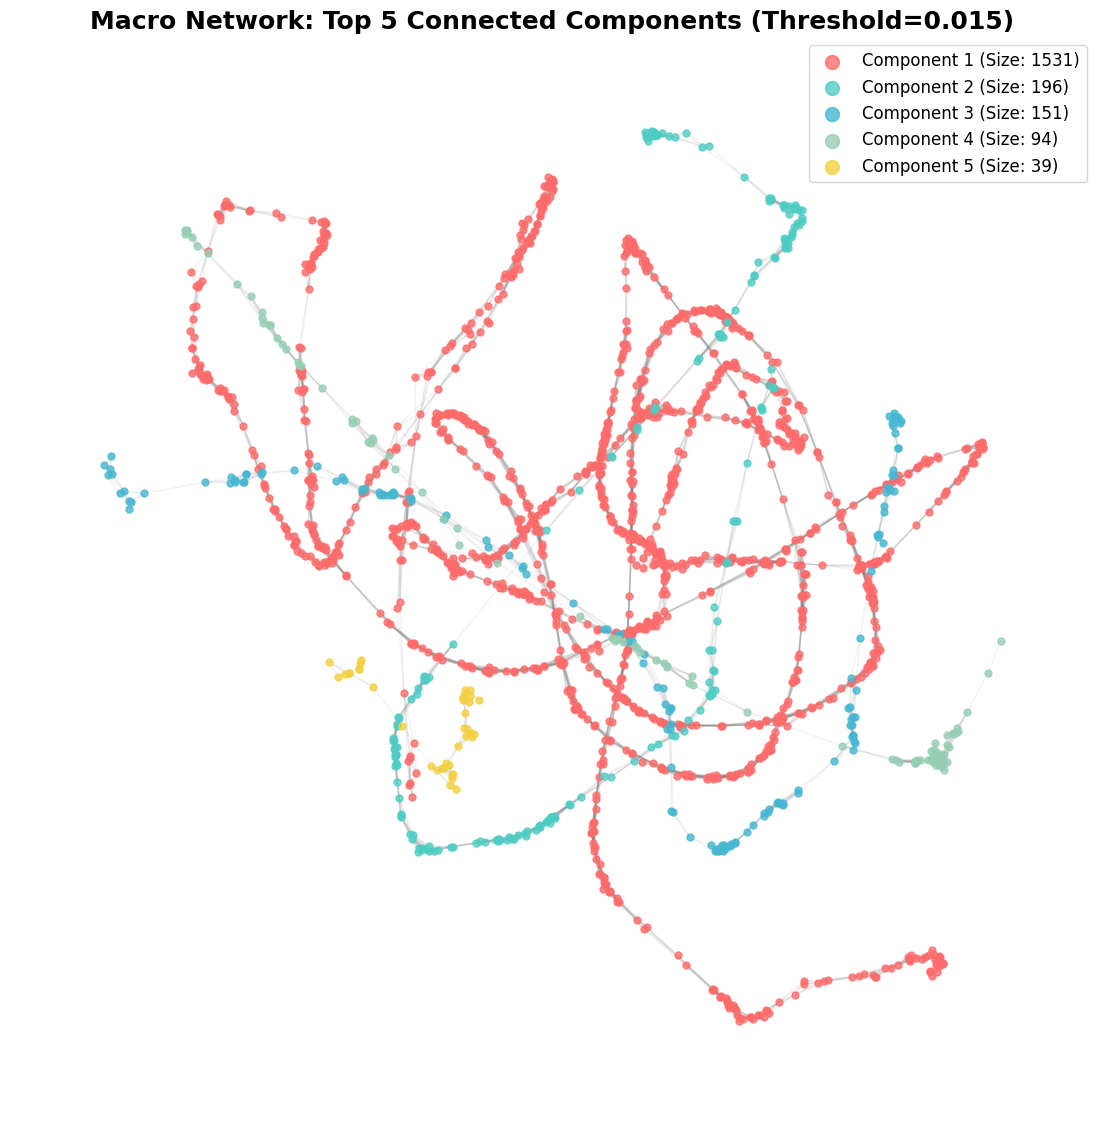

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import time

print("开始准备宏观网络可视化数据...")
start_time = time.time()

# 1. 提取前 5 大连通分量的节点集合
components = list(nx.connected_components(G_views))
components.sort(key=len, reverse=True)
top_5_components = components[:5]

# 构建一个只包含这前 5 大分量的子图
nodes_to_draw = set()
for comp in top_5_components:
    nodes_to_draw.update(comp)

G_top5 = G_views.subgraph(nodes_to_draw)

print(f"正在计算网络布局 (包含 {G_top5.number_of_nodes()} 个节点)，请稍候...")
# 2. 计算节点坐标 (适当调整了 k 值，让聚类之间推得更开)
pos = nx.spring_layout(G_top5, k=0.1, iterations=40, seed=42)
print(f"布局计算完成！耗时: {time.time() - start_time:.2f} 秒")

# 3. 开始绘图
plt.figure(figsize=(14, 14))

# 为前 5 个分量准备 5 种好看的颜色
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#F4D03F']

# 循环画出每个分量的节点
for i, comp in enumerate(top_5_components):
    nx.draw_networkx_nodes(G_top5, pos,
                           nodelist=list(comp),
                           node_size=25,  # 稍微调大节点尺寸
                           node_color=colors[i],
                           alpha=0.8,
                           label=f'Component {i+1} (Size: {len(comp)})')

# 画出连边 (透明度设得很低，作为背景)
nx.draw_networkx_edges(G_top5, pos, alpha=0.1, edge_color='gray')

# 4. 图表装饰与保存
plt.title(f"Macro Network: Top 5 Connected Components (Threshold={threshold_views})", fontsize=18, fontweight='bold')
plt.legend(markerscale=2, fontsize=12, loc='upper right')
plt.axis('off')  # 隐藏坐标轴

# 保存图片为 4_名称 格式
plt.savefig('4_macro_network_components.png', dpi=300, bbox_inches='tight')
print("\n已保存图片: 4_macro_network_components.png")
plt.show()

正在 LCC (n=1531) 内部构建标签相似度网络, 阈值: 0.1...
建图完成！耗时: 1.53 秒

--- 内容网络诊断 (Jaccard >= 0.1) ---
节点数: 1531
连边数: 10757
孤立节点数: 296 (即没有任何视频与它有 10.0% 以上的标签重合)
平均聚类系数: 0.4997 (期望在 0.2 - 0.6 之间)

已保存图片: 5_jaccard_distribution.png


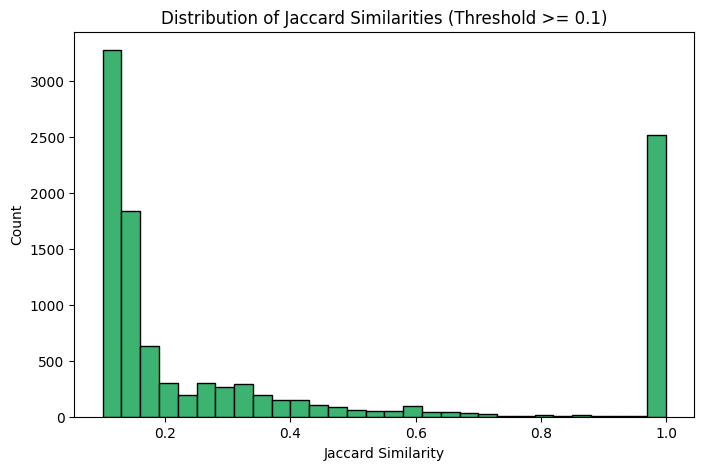

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. 设定标签相似度阈值
# ==========================================
# 去重后，0.1 是一个比较合理的测试起点
threshold_jaccard = 0.1

print(f"正在 LCC (n={G_lcc.number_of_nodes()}) 内部构建标签相似度网络, 阈值: {threshold_jaccard}...")
start_time = time.time()

# 定义 Jaccard 相似度函数
def get_jaccard_sim(list1, list2):
    s1 = set(list1)
    s2 = set(list2)
    if not s1 or not s2: return 0
    return len(s1.intersection(s2)) / len(s1.union(s2))

# ==========================================
# 2. 构建精细内容网络 G_tags
# ==========================================
G_tags = nx.Graph()

# 导入 LCC 中的节点
lcc_node_list = list(G_lcc.nodes())
for n in lcc_node_list:
    G_tags.add_node(n, **G_lcc.nodes[n])

# 计算两两之间的相似度 (1531个节点，约117万次对比，很快就能跑完)
edges_to_add = []
node_data_list = [(n, G_lcc.nodes[n]['tags']) for n in lcc_node_list]

for i in range(len(node_data_list)):
    u, tags_u = node_data_list[i]
    for j in range(i + 1, len(node_data_list)):
        v, tags_v = node_data_list[j]

        sim = get_jaccard_sim(tags_u, tags_v)
        if sim >= threshold_jaccard:
            edges_to_add.append((u, v, sim))

G_tags.add_weighted_edges_from(edges_to_add)
print(f"建图完成！耗时: {time.time() - start_time:.2f} 秒")

# ==========================================
# 3. 精细网络诊断
# ==========================================
print(f"\n--- 内容网络诊断 (Jaccard >= {threshold_jaccard}) ---")
print(f"节点数: {G_tags.number_of_nodes()}")
print(f"连边数: {G_tags.number_of_edges()}")

isolates = list(nx.isolates(G_tags))
print(f"孤立节点数: {len(isolates)} (即没有任何视频与它有 {threshold_jaccard*100}% 以上的标签重合)")

# 计算平均聚类系数
avg_clustering = nx.average_clustering(G_tags)
print(f"平均聚类系数: {avg_clustering:.4f} (期望在 0.2 - 0.6 之间)")

# ==========================================
# 4. 可视化：保存 Jaccard 分布图
# ==========================================
plt.figure(figsize=(8, 5))
edge_weights = [d['weight'] for u, v, d in G_tags.edges(data=True)]

if len(edge_weights) > 0:
    plt.hist(edge_weights, bins=30, color='mediumseagreen', edgecolor='black')
    plt.title(f'Distribution of Jaccard Similarities (Threshold >= {threshold_jaccard})')
    plt.xlabel('Jaccard Similarity')
    plt.ylabel('Count')
else:
    plt.text(0.5, 0.5, 'No edges created', ha='center', va='center')

plt.savefig('5_jaccard_distribution.png', dpi=300, bbox_inches='tight')
print("\n已保存图片: 5_jaccard_distribution.png")
plt.show()

开始进行中心性分析与全网络可视化...
剔除孤立节点后，当前核心网络包含 1235 个节点。
正在计算度中心性 (Degree)...
正在计算介数中心性 (Betweenness) - 这可能需要十几秒...
正在计算特征向量中心性 (Eigenvector)...

--- Top 20% 中心性节点分析 ---
Top 20% 节点数量为: 247 个
同时具有极高 度中心性(Degree) 和 介数中心性(Betweenness) 的节点有: 60 个
重合率: 24.29%
Top 5 重合节点的标题示例:
 - Carrie Underwood - The Champion (Official Lyric Video) ft. Ludacris
 - MØ - When I Was Young (Official Video)
 - Ansel Elgort - Supernova
 - 6IX9INE Billy (WSHH Exclusive - Official Audio)
 - Sade - Flower of the Universe (From Disney's A Wrinkle in Time) (Official Lyric Video)

正在计算网络布局，请稍候...

可视化完成！总耗时: 2.77 秒
已保存图片: 6_micro_network_centrality.png


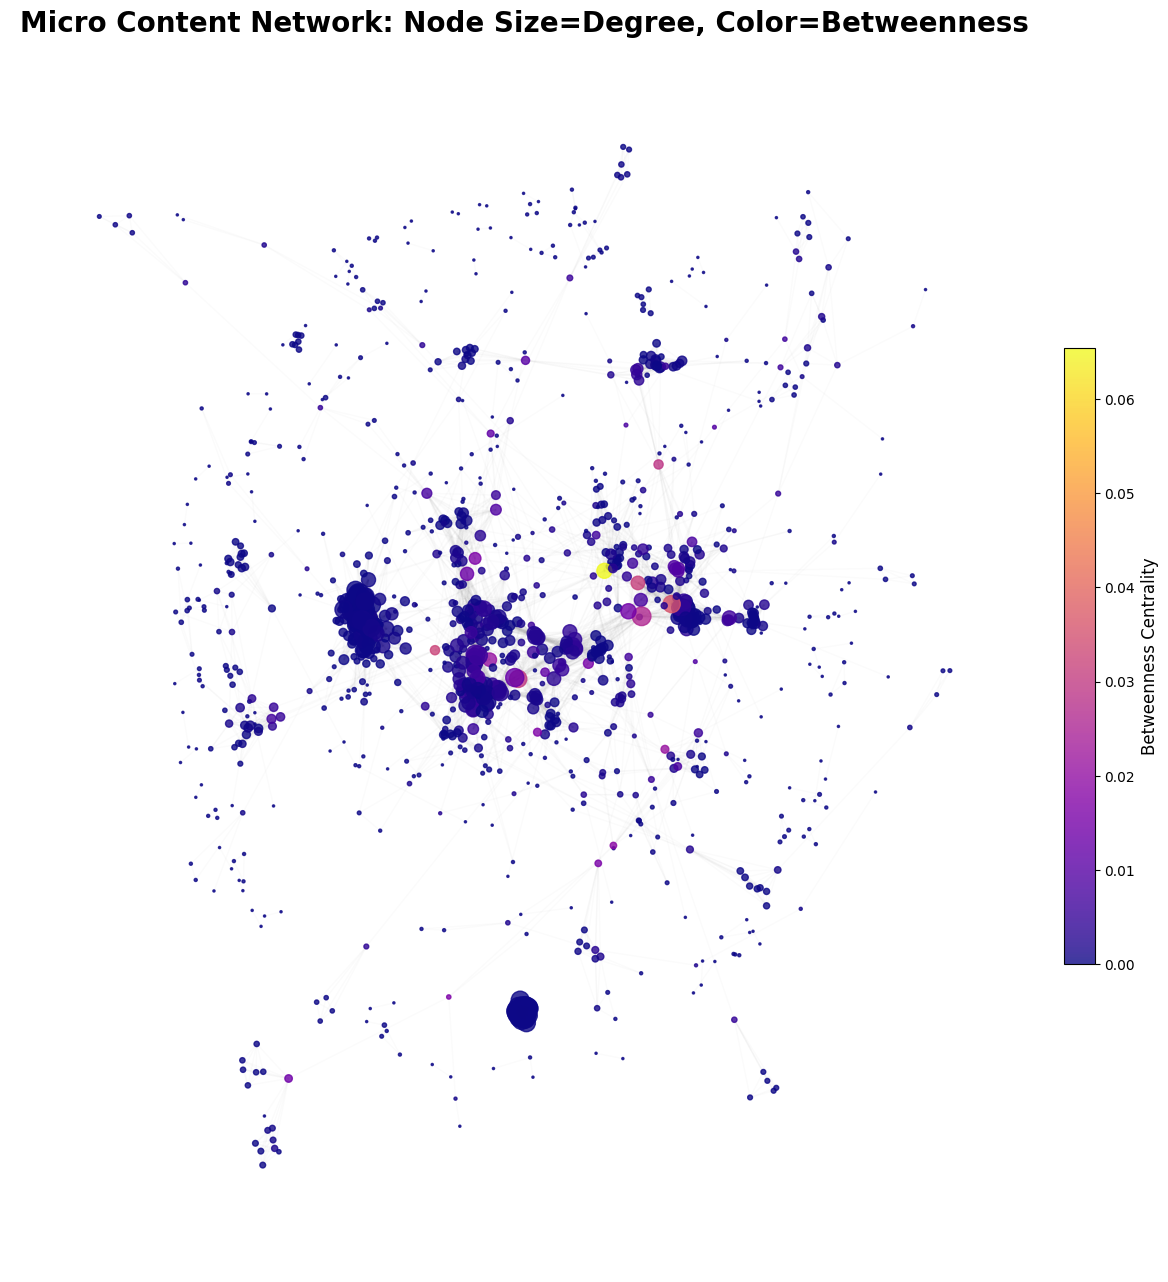

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import numpy as np

print("开始进行中心性分析与全网络可视化...")
start_time = time.time()

# ==========================================
# 1. 清理网络：剔除孤立节点
# ==========================================
G_core = G_tags.copy()
isolates = list(nx.isolates(G_core))
G_core.remove_nodes_from(isolates)
num_core_nodes = G_core.number_of_nodes()
print(f"剔除孤立节点后，当前核心网络包含 {num_core_nodes} 个节点。")

# ==========================================
# 2. 计算三大中心性指标
# ==========================================
print("正在计算度中心性 (Degree)...")
deg_cent = nx.degree_centrality(G_core)

print("正在计算介数中心性 (Betweenness) - 这可能需要十几秒...")
# 介数中心性计算量较大，但 1200 个节点在可接受范围内
bet_cent = nx.betweenness_centrality(G_core)

print("正在计算特征向量中心性 (Eigenvector)...")
eig_cent = nx.eigenvector_centrality(G_core, max_iter=1000)

# 将中心性属性保存回图中，方便后续社区分析使用
nx.set_node_attributes(G_core, deg_cent, 'degree_cent')
nx.set_node_attributes(G_core, bet_cent, 'betweenness_cent')
nx.set_node_attributes(G_core, eig_cent, 'eigenvector_cent')

# ==========================================
# 3. 回应项目要求：Top 20% 的节点重合度分析
# ==========================================
top_20_percent_count = int(num_core_nodes * 0.2)

# 按中心性值降序排列获取 Top 20% 的节点列表
top_deg = sorted(deg_cent, key=deg_cent.get, reverse=True)[:top_20_percent_count]
top_bet = sorted(bet_cent, key=bet_cent.get, reverse=True)[:top_20_percent_count]

# 取交集
overlap_nodes = set(top_deg).intersection(set(top_bet))
overlap_ratio = len(overlap_nodes) / top_20_percent_count * 100

print(f"\n--- Top 20% 中心性节点分析 ---")
print(f"Top 20% 节点数量为: {top_20_percent_count} 个")
print(f"同时具有极高 度中心性(Degree) 和 介数中心性(Betweenness) 的节点有: {len(overlap_nodes)} 个")
print(f"重合率: {overlap_ratio:.2f}%")
print("Top 5 重合节点的标题示例:")
for n in list(overlap_nodes)[:5]:
    print(f" - {G_core.nodes[n]['title']}")

# ==========================================
# 4. 微观网络全景可视化
# ==========================================
print("\n正在计算网络布局，请稍候...")
# 使用 spring_layout，k值稍微调大一点防止节点挤压
pos = nx.spring_layout(G_core, k=0.15, iterations=40, seed=42)

plt.figure(figsize=(16, 16))

# 节点大小映射到 度中心性 (放大系数让区分度更明显)
node_sizes = [deg_cent[n] * 3000 for n in G_core.nodes()]

# 节点颜色映射到 介数中心性 (高介数节点会显示为高亮颜色，它们是连接不同社区的桥梁)
node_colors = [bet_cent[n] for n in G_core.nodes()]

# 画边
nx.draw_networkx_edges(G_core, pos, alpha=0.03, edge_color='gray')

# 画节点
nodes = nx.draw_networkx_nodes(G_core, pos,
                               node_size=node_sizes,
                               node_color=node_colors,
                               cmap=plt.cm.plasma, # 使用 plasma 颜色映射
                               alpha=0.8)

# 添加颜色条
cbar = plt.colorbar(nodes, shrink=0.5, pad=0.02)
cbar.set_label('Betweenness Centrality', fontsize=12)

plt.title("Micro Content Network: Node Size=Degree, Color=Betweenness", fontsize=20, fontweight='bold')
plt.axis('off')

plt.savefig('6_micro_network_centrality.png', dpi=300, bbox_inches='tight')
print(f"\n可视化完成！总耗时: {time.time() - start_time:.2f} 秒")
print("已保存图片: 6_micro_network_centrality.png")
plt.show()

Running Louvain community detection...
Louvain finished. Total communities: 107
 - Processing community 1 (nodes: 297)
 - Processing community 2 (nodes: 159)
No mask image found. Using default rectangle shape.

Generating word clouds...
Saved figure: 7_Cluster_1_YouTube_WordCloud.png


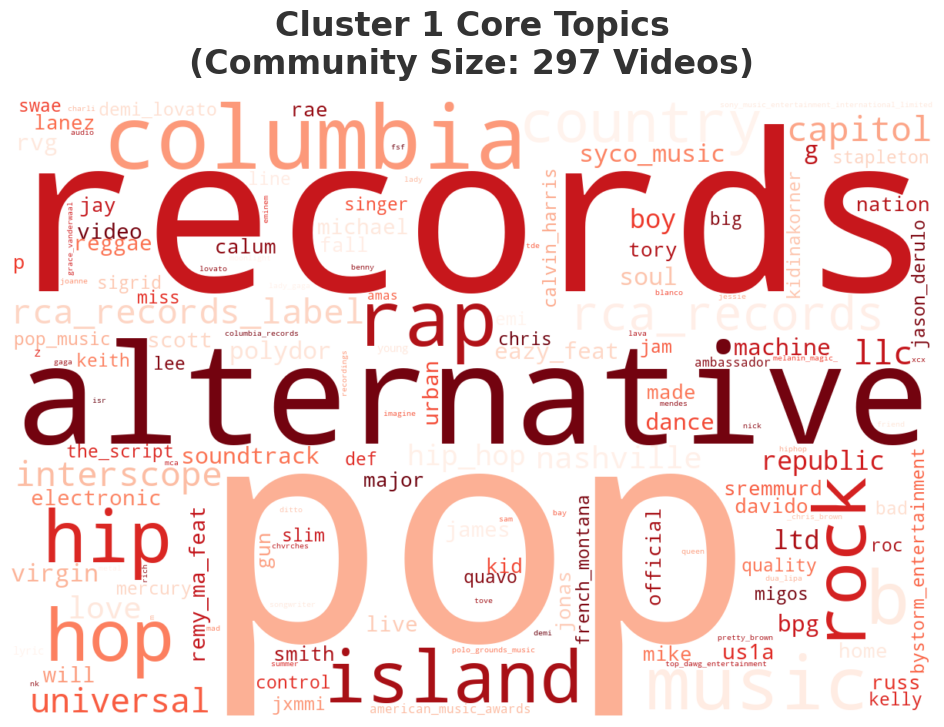

Saved figure: 7_Cluster_2_YouTube_WordCloud.png


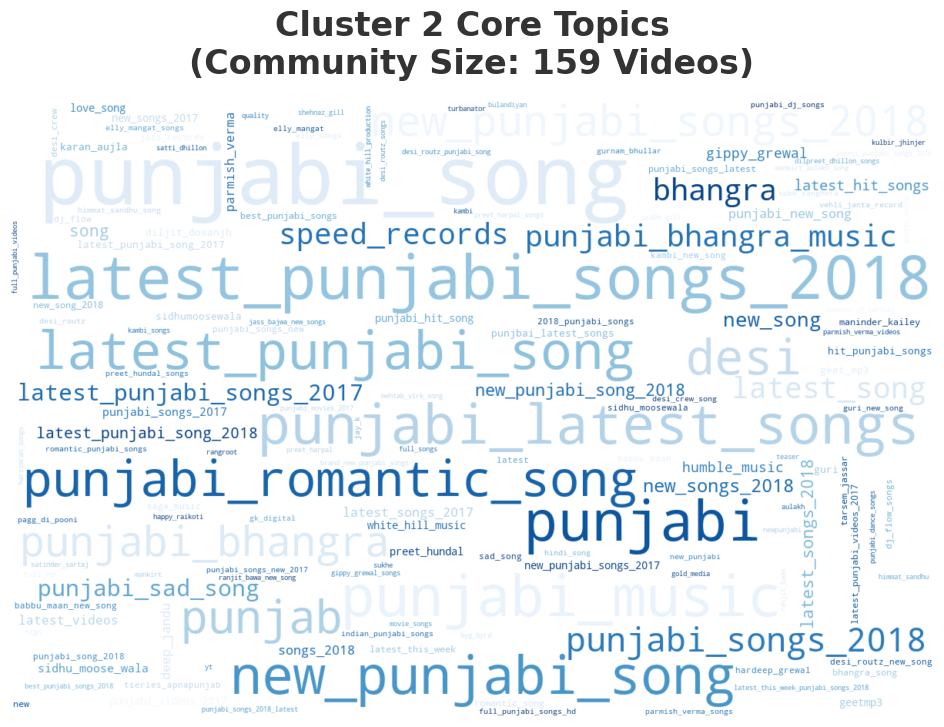


Done. Total time: 1.70 s


In [7]:
import networkx as nx
import networkx.algorithms.community as nx_comm
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
from PIL import Image
import time
from pathlib import Path

print("Running Louvain community detection...")
start_time = time.time()

# ==========================================
# 1. Community detection (Louvain)
# ==========================================
communities = nx_comm.louvain_communities(G_core, weight='weight', resolution=1.0)
communities = sorted(communities, key=len, reverse=True)

print(f"Louvain finished. Total communities: {len(communities)}")

# ==========================================
# 2. Build tag text for top-2 communities
# ==========================================
num_top_communities = min(2, len(communities))
community_tags_text = []

for i in range(num_top_communities):
    comp_nodes = list(communities[i])
    print(f" - Processing community {i+1} (nodes: {len(comp_nodes)})")

    all_tags_in_comp = []
    for n in comp_nodes:
        all_tags_in_comp.extend(G_core.nodes[n]['tags'])

    text = " ".join([tag.replace(" ", "_") for tag in all_tags_in_comp if len(tag) > 2])
    community_tags_text.append(text)

# ==========================================
# 3. Optional local mask loading
# ==========================================
yt_mask = None
mask_candidates = [
    Path('WordCloud.png'),
    Path('assets/WordCloud.png'),
    Path('images/WordCloud.png')
]

for mp in mask_candidates:
    if mp.exists():
        yt_mask = np.array(Image.open(mp))
        print(f"Mask found: {mp.resolve()}")
        break

if yt_mask is None:
    print("No mask image found. Using default rectangle shape.")

# ==========================================
# 4. Generate word clouds
# ==========================================
print("\nGenerating word clouds...")

colormaps = ['Reds', 'Blues']

for i in range(num_top_communities):
    wc = WordCloud(
        background_color='white',
        mask=yt_mask,
        colormap=colormaps[i],
        contour_width=2 if yt_mask is not None else 0,
        contour_color='firebrick' if i == 0 else 'navy',
        collocations=False,
        max_words=150,
        width=1200,
        height=800
    ).generate(community_tags_text[i])

    plt.figure(figsize=(12, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(
        f'Cluster {i+1} Core Topics\n(Community Size: {len(communities[i])} Videos)',
        fontsize=24,
        fontweight='bold',
        pad=20,
        color='#333333'
    )
    plt.axis('off')

    output_filename = f'7_Cluster_{i+1}_YouTube_WordCloud.png'
    plt.savefig(output_filename, dpi=300, transparent=False, bbox_inches='tight')
    print(f"Saved figure: {output_filename}")
    plt.show()

print(f"\nDone. Total time: {time.time() - start_time:.2f} s")



In [8]:
import networkx as nx
import time

print("正在计算网络直径与平均最短路径...")
start_time = time.time()

# 提取 G_core 中的最大连通分量，因为最短路径只能在完全连通的图里算
components = list(nx.connected_components(G_core))
G_core_lcc = G_core.subgraph(max(components, key=len))

print(f"用于计算的核心连通子图包含 {G_core_lcc.number_of_nodes()} 个节点。")

# 计算平均最短路径
avg_path_length = nx.average_shortest_path_length(G_core_lcc)
print(f"--> 平均最短路径 (Average Shortest Path): {avg_path_length:.4f}")

# 计算网络直径
diameter = nx.diameter(G_core_lcc)
print(f"--> 网络直径 (Diameter): {diameter}")

print(f"\n计算完成！耗时: {time.time() - start_time:.2f} 秒")

正在计算网络直径与平均最短路径...
用于计算的核心连通子图包含 716 个节点。
--> 平均最短路径 (Average Shortest Path): 4.8596
--> 网络直径 (Diameter): 14

计算完成！耗时: 2.61 秒


--- Top-10% overlap (Degree vs Betweenness) ---
Core nodes: 1235
Top-10% size: 124
Overlap count: 7
Overlap ratio: 5.65%

Reference (Top-20%):
Size: 247, overlap: 60, ratio: 24.29%
Saved figure: 8_top10_overlap_analysis.png


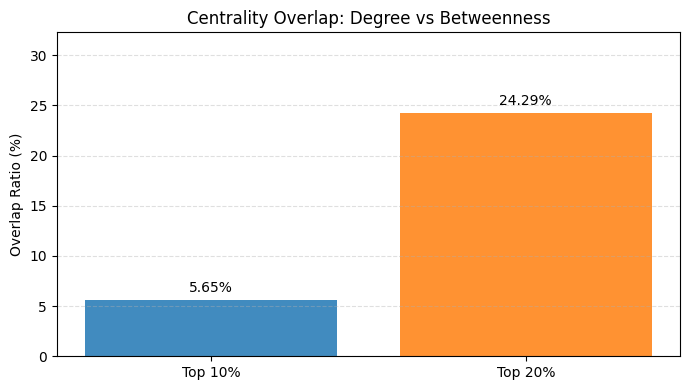

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Additional Analysis A: Top-10% centrality overlap
# ==========================================
if 'G_core' not in globals() or 'deg_cent' not in globals() or 'bet_cent' not in globals():
    raise RuntimeError('Please run the centrality analysis cell first (G_core, deg_cent, bet_cent).')

num_core_nodes = G_core.number_of_nodes()
top_10_count = max(1, int(np.ceil(num_core_nodes * 0.10)))
top_20_count = max(1, int(np.ceil(num_core_nodes * 0.20)))

top_deg_10 = sorted(deg_cent, key=deg_cent.get, reverse=True)[:top_10_count]
top_bet_10 = sorted(bet_cent, key=bet_cent.get, reverse=True)[:top_10_count]
overlap_10 = set(top_deg_10).intersection(set(top_bet_10))
overlap_ratio_10 = len(overlap_10) / top_10_count * 100

top_deg_20 = sorted(deg_cent, key=deg_cent.get, reverse=True)[:top_20_count]
top_bet_20 = sorted(bet_cent, key=bet_cent.get, reverse=True)[:top_20_count]
overlap_20 = set(top_deg_20).intersection(set(top_bet_20))
overlap_ratio_20 = len(overlap_20) / top_20_count * 100

print('--- Top-10% overlap (Degree vs Betweenness) ---')
print(f'Core nodes: {num_core_nodes}')
print(f'Top-10% size: {top_10_count}')
print(f'Overlap count: {len(overlap_10)}')
print(f'Overlap ratio: {overlap_ratio_10:.2f}%')

print('\nReference (Top-20%):')
print(f'Size: {top_20_count}, overlap: {len(overlap_20)}, ratio: {overlap_ratio_20:.2f}%')

plt.figure(figsize=(7, 4))
x_labels = ['Top 10%', 'Top 20%']
y_vals = [overlap_ratio_10, overlap_ratio_20]
bars = plt.bar(x_labels, y_vals, color=['#1f77b4', '#ff7f0e'], alpha=0.85)
for bar, val in zip(bars, y_vals):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.2f}%', ha='center', va='bottom')
plt.ylabel('Overlap Ratio (%)')
plt.title('Centrality Overlap: Degree vs Betweenness')
plt.ylim(0, max(y_vals) + 8)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('8_top10_overlap_analysis.png', dpi=300, bbox_inches='tight')
print('Saved figure: 8_top10_overlap_analysis.png')
plt.show()



--- Community algorithm comparison (sorted by modularity) ---
        Algorithm  Communities  Modularity  Runtime_s
          Louvain          104      0.6248     0.0400
Greedy Modularity          108      0.6230     0.2495
Label Propagation          184      0.6021     0.0280

Top-5 community sizes by algorithm:
 - Louvain: [267, 159, 110, 70, 60]
 - Greedy Modularity: [292, 159, 145, 81, 70]
 - Label Propagation: [142, 70, 64, 58, 56]
Saved figure: 9_community_algorithm_comparison.png


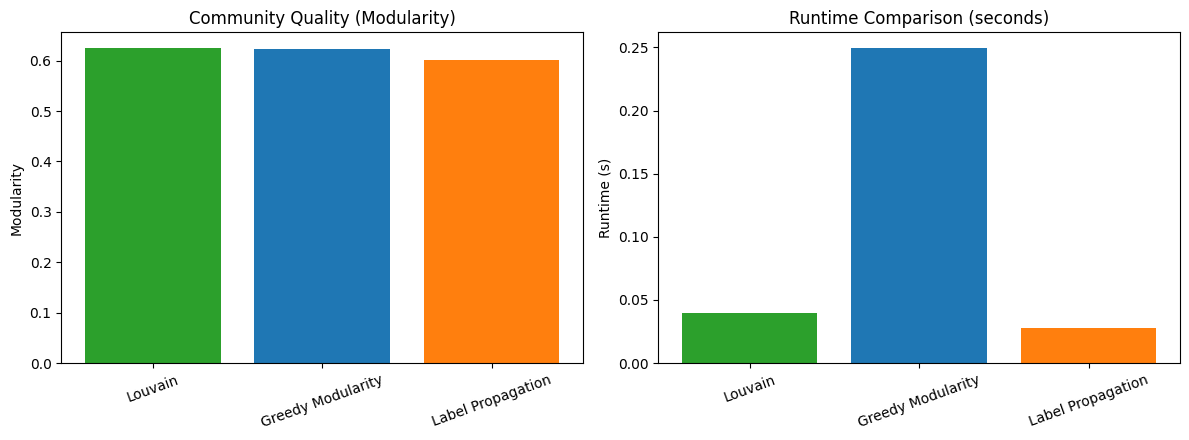

In [10]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import networkx.algorithms.community as nx_comm

# ==========================================
# Additional Analysis B: Community algorithm comparison
# Louvain vs Greedy Modularity vs Label Propagation
# ==========================================
if 'G_core' not in globals():
    raise RuntimeError('Please run the cell that creates G_core first.')

results = []
partitions = {}

# 1) Louvain
t0 = time.time()
comm_louvain = nx_comm.louvain_communities(G_core, weight='weight', resolution=1.0, seed=42)
t_louvain = time.time() - t0
mod_louvain = nx_comm.modularity(G_core, comm_louvain, weight='weight')
results.append({'Algorithm': 'Louvain', 'Communities': len(comm_louvain), 'Modularity': mod_louvain, 'Runtime_s': t_louvain})
partitions['Louvain'] = comm_louvain

# 2) Greedy Modularity
t0 = time.time()
comm_greedy = list(nx_comm.greedy_modularity_communities(G_core, weight='weight'))
t_greedy = time.time() - t0
mod_greedy = nx_comm.modularity(G_core, comm_greedy, weight='weight')
results.append({'Algorithm': 'Greedy Modularity', 'Communities': len(comm_greedy), 'Modularity': mod_greedy, 'Runtime_s': t_greedy})
partitions['Greedy Modularity'] = comm_greedy

# 3) Asynchronous Label Propagation
t0 = time.time()
comm_lpa = list(nx_comm.asyn_lpa_communities(G_core, weight='weight', seed=42))
t_lpa = time.time() - t0
mod_lpa = nx_comm.modularity(G_core, comm_lpa, weight='weight')
results.append({'Algorithm': 'Label Propagation', 'Communities': len(comm_lpa), 'Modularity': mod_lpa, 'Runtime_s': t_lpa})
partitions['Label Propagation'] = comm_lpa

df_compare = pd.DataFrame(results).sort_values('Modularity', ascending=False).reset_index(drop=True)
print('--- Community algorithm comparison (sorted by modularity) ---')
print(df_compare.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nTop-5 community sizes by algorithm:')
for name, comms in partitions.items():
    sizes = sorted([len(c) for c in comms], reverse=True)
    print(f' - {name}: {sizes[:5]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(df_compare['Algorithm'], df_compare['Modularity'], color=['#2ca02c', '#1f77b4', '#ff7f0e'])
axes[0].set_title('Community Quality (Modularity)')
axes[0].set_ylabel('Modularity')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(df_compare['Algorithm'], df_compare['Runtime_s'], color=['#2ca02c', '#1f77b4', '#ff7f0e'])
axes[1].set_title('Runtime Comparison (seconds)')
axes[1].set_ylabel('Runtime (s)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('9_community_algorithm_comparison.png', dpi=300, bbox_inches='tight')
print('Saved figure: 9_community_algorithm_comparison.png')
plt.show()



--- Degree Distribution Model Check (Tail) ---
Core graph nodes: 1235, edges: 10757
Mean degree (lambda for Poisson): 17.4202
Power-law kmin: 5, fitted gamma: 1.6905
KS distance (Power-law): 0.2446
KS distance (Poisson): 0.3607
Conclusion: Tail behavior is closer to Power-law than Poisson.
Saved figure: 10_degree_distribution_fit.png


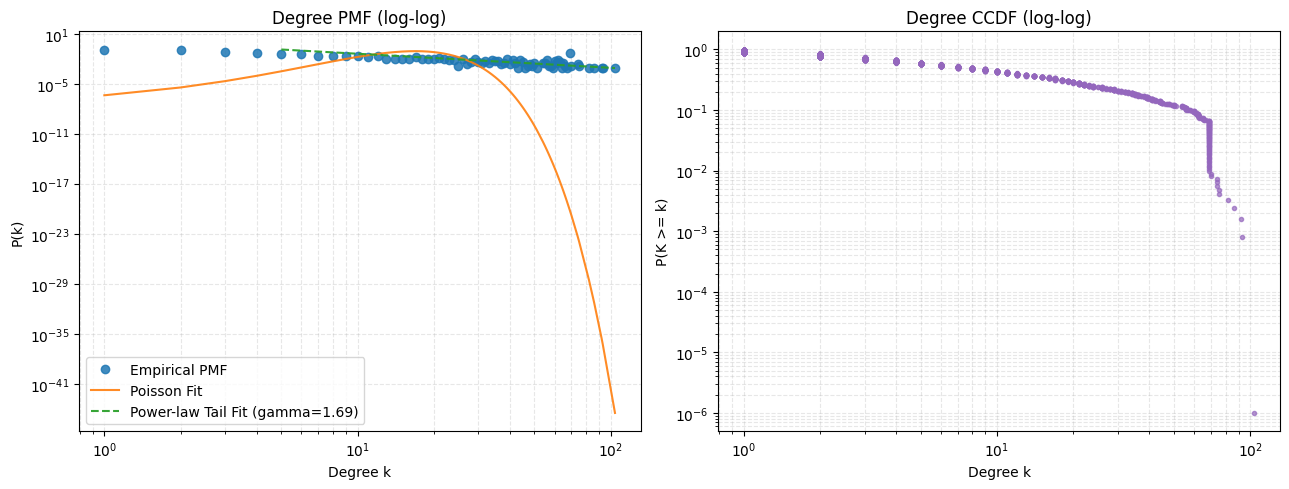

In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Additional Analysis C: Degree distribution deep dive
# Power-law vs Poisson
# ==========================================
if 'G_core' not in globals():
    raise RuntimeError('Please run the cell that creates G_core first.')

degrees = np.array([d for _, d in G_core.degree()])
k_vals, counts = np.unique(degrees, return_counts=True)
p_emp = counts / counts.sum()

# Poisson fit (lambda = mean degree)
lam = degrees.mean()
log_fact = np.array([math.lgamma(int(k) + 1) for k in k_vals], dtype=float)
log_poi = k_vals * np.log(lam) - lam - log_fact
p_poi_raw = np.exp(log_poi)
p_poi = p_poi_raw / p_poi_raw.sum()

# Power-law fit (discrete tail approximation)
kmin = 5
tail = degrees[degrees >= kmin]
if len(tail) < 30:
    raise RuntimeError(f'Tail sample too small (len={len(tail)}). Try a smaller kmin.')
gamma_hat = 1 + len(tail) / np.sum(np.log(tail / (kmin - 0.5)))
k_tail = k_vals[k_vals >= kmin]
emp_tail = p_emp[k_vals >= kmin]
emp_tail = emp_tail / emp_tail.sum()

p_pl_raw = k_tail.astype(float) ** (-gamma_hat)
p_pl = p_pl_raw / p_pl_raw.sum()

# Compare model errors on tail
poi_tail = p_poi[k_vals >= kmin]
poi_tail = poi_tail / poi_tail.sum()

ks_pl = np.max(np.abs(np.cumsum(emp_tail) - np.cumsum(p_pl)))
ks_poi = np.max(np.abs(np.cumsum(emp_tail) - np.cumsum(poi_tail)))

print('--- Degree Distribution Model Check (Tail) ---')
print(f'Core graph nodes: {G_core.number_of_nodes()}, edges: {G_core.number_of_edges()}')
print(f'Mean degree (lambda for Poisson): {lam:.4f}')
print(f'Power-law kmin: {kmin}, fitted gamma: {gamma_hat:.4f}')
print(f'KS distance (Power-law): {ks_pl:.4f}')
print(f'KS distance (Poisson): {ks_poi:.4f}')

if ks_pl < ks_poi:
    print('Conclusion: Tail behavior is closer to Power-law than Poisson.')
else:
    print('Conclusion: Tail is not clearly better fit by Power-law; further tests are needed.')

# Visualization: PMF comparison + CCDF
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].loglog(k_vals, p_emp, 'o', label='Empirical PMF', alpha=0.85)
axes[0].loglog(k_vals, p_poi, '-', label='Poisson Fit', alpha=0.9)
axes[0].loglog(k_tail, p_pl * (emp_tail.sum()), '--', label=f'Power-law Tail Fit (gamma={gamma_hat:.2f})', alpha=0.95)
axes[0].set_title('Degree PMF (log-log)')
axes[0].set_xlabel('Degree k')
axes[0].set_ylabel('P(k)')
axes[0].legend()
axes[0].grid(True, which='both', ls='--', alpha=0.3)

deg_sorted = np.sort(degrees)
ccdf_y = 1.0 - (np.arange(1, len(deg_sorted) + 1) / len(deg_sorted))
axes[1].loglog(deg_sorted, np.maximum(ccdf_y, 1e-6), '.', alpha=0.7, color='tab:purple')
axes[1].set_title('Degree CCDF (log-log)')
axes[1].set_xlabel('Degree k')
axes[1].set_ylabel('P(K >= k)')
axes[1].grid(True, which='both', ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig('10_degree_distribution_fit.png', dpi=300, bbox_inches='tight')
print('Saved figure: 10_degree_distribution_fit.png')
plt.show()



In [12]:
import networkx as nx
import numpy as np
import pandas as pd

# ==========================================
# Additional Analysis D: Compare with ER / BA / WS models
# (No extra figure generated; prints a comparison table)
# ==========================================
if 'G_core' not in globals():
    raise RuntimeError('Please run the previous cells first to create G_core.')

# Use largest connected component of the real network for fair path-based comparison
real_components = list(nx.connected_components(G_core))
G_real_lcc = G_core.subgraph(max(real_components, key=len)).copy()

n = G_real_lcc.number_of_nodes()
m = G_real_lcc.number_of_edges()
avg_deg_real = (2 * m) / n

print('--- Real graph (largest CC) baseline ---')
print(f'n={n}, m={m}, avg_degree={avg_deg_real:.4f}')

# Parameter matching
p_er = (2 * m) / (n * (n - 1))
m_attach = max(1, int(round(m / n)))

k_ws = max(2, int(round(avg_deg_real)))
if k_ws % 2 == 1:
    k_ws += 1
if k_ws >= n:
    k_ws = n - 1 if (n - 1) % 2 == 0 else n - 2
k_ws = max(2, k_ws)
p_ws = 0.10

seed = 42
G_er = nx.gnm_random_graph(n=n, m=m, seed=seed)
G_ba = nx.barabasi_albert_graph(n=n, m=m_attach, seed=seed)
G_ws = nx.watts_strogatz_graph(n=n, k=k_ws, p=p_ws, seed=seed)

def largest_cc_subgraph(G):
    comps = list(nx.connected_components(G))
    lcc = max(comps, key=len)
    return G.subgraph(lcc).copy(), len(lcc), len(comps)

def ks_2sample_deg(real_deg, model_deg):
    # Lightweight 2-sample KS for discrete degree values
    real = np.sort(np.asarray(real_deg, dtype=float))
    model = np.sort(np.asarray(model_deg, dtype=float))
    vals = np.unique(np.concatenate([real, model]))
    cdf_r = np.searchsorted(real, vals, side='right') / len(real)
    cdf_m = np.searchsorted(model, vals, side='right') / len(model)
    return float(np.max(np.abs(cdf_r - cdf_m)))

def summarize_graph(name, G, ref_deg):
    G_lcc, lcc_size, n_comp = largest_cc_subgraph(G)
    deg = np.array([d for _, d in G.degree()])
    deg_lcc = np.array([d for _, d in G_lcc.degree()])

    row = {
        'Graph': name,
        'n': G.number_of_nodes(),
        'm': G.number_of_edges(),
        'Density': nx.density(G),
        'AvgDegree': float(deg.mean()) if len(deg) else 0.0,
        'AvgClustering': nx.average_clustering(G),
        'Components': n_comp,
        'LCC_Ratio': lcc_size / G.number_of_nodes(),
        'AvgPath_LCC': nx.average_shortest_path_length(G_lcc),
        'Diameter_LCC': nx.diameter(G_lcc),
        'DegKS_vs_Real': ks_2sample_deg(ref_deg, deg_lcc)
    }
    return row

real_deg_lcc = np.array([d for _, d in G_real_lcc.degree()])

rows = []
rows.append(summarize_graph('Real (YouTube LCC)', G_real_lcc, real_deg_lcc))
rows.append(summarize_graph(f'ER (p={p_er:.4f})', G_er, real_deg_lcc))
rows.append(summarize_graph(f'BA (m={m_attach})', G_ba, real_deg_lcc))
rows.append(summarize_graph(f'WS (k={k_ws}, p={p_ws})', G_ws, real_deg_lcc))

df_models = pd.DataFrame(rows)

# Cleaner display
fmt_cols = ['Density', 'AvgDegree', 'AvgClustering', 'LCC_Ratio', 'AvgPath_LCC', 'DegKS_vs_Real']
for c in fmt_cols:
    df_models[c] = df_models[c].astype(float)

print('\n--- Structural comparison: Real vs ER / BA / WS ---')
print(df_models.to_string(index=False, formatters={
    'Density': lambda x: f'{x:.4f}',
    'AvgDegree': lambda x: f'{x:.4f}',
    'AvgClustering': lambda x: f'{x:.4f}',
    'LCC_Ratio': lambda x: f'{x:.4f}',
    'AvgPath_LCC': lambda x: f'{x:.4f}',
    'DegKS_vs_Real': lambda x: f'{x:.4f}'
}))

# Optional: save table for report usage
df_models.to_csv('11_model_comparison_table.csv', index=False)
print('Saved table: 11_model_comparison_table.csv')


--- Real graph (largest CC) baseline ---
n=716, m=5212, avg_degree=14.5587

--- Structural comparison: Real vs ER / BA / WS ---
             Graph   n    m Density AvgDegree AvgClustering  Components LCC_Ratio AvgPath_LCC  Diameter_LCC DegKS_vs_Real
Real (YouTube LCC) 716 5212  0.0204   14.5587        0.6283           1    1.0000      4.8596            14        0.0000
     ER (p=0.0204) 716 5212  0.0204   14.5587        0.0209           1    1.0000      2.7353             4        0.4316
          BA (m=7) 716 4963  0.0194   13.8631        0.0597           1    1.0000      2.6564             4        0.4078
  WS (k=16, p=0.1) 716 5728  0.0224   16.0000        0.5144           1    1.0000      3.3355             5        0.5866
Saved table: 11_model_comparison_table.csv
